# Benchmark: Python puro vs Numba

Comparación del tiempo de ejecución del núcleo Monte Carlo (`metropolis_sweep`)
en su versión interpretada por Python y en su versión compilada con `@njit`.

Se mide **únicamente el barrido de Metrópolis**, no la simulación completa, porque
la construcción de la red y el análisis posterior no son el cuello de botella.

> Este notebook debe estar en la misma carpeta que `funciones.py` y `parametros.py`.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from parametros import cell, ti_positions, d_anillos, J_meV, tol, k_B, seed
from funciones  import (construir_supercelda, construir_libreta_vecinos,
                        sembrar_numba,
                        calcular_campo_local, metropolis_step, metropolis_sweep)

---
## 1. Versiones en Python puro

Las funciones de `funciones.py` ya llevan el decorador `@njit`. Para comparar hace
falta tener también la cadena sin compilar.

No sirve usar `metropolis_sweep.py_func`: eso ejecuta el bucle en Python, pero por
dentro sigue llamando a `metropolis_step` **compilada**. Hay que replicar la cadena
completa, y por eso las tres funciones se redefinen aquí con el sufijo `_py`.

El cuerpo es idéntico al de `funciones.py` — lo único que cambia es el decorador.

In [2]:
def calcular_campo_local_py(spins, neighbor_idx_i, neighbor_J_i):
    """
    Campo local sobre el sitio i:  h_i = sum_j  J_ij * S_j  (en meV).
    Es la "presión neta" que ejercen los vecinos sobre el sitio i.
    """
    return np.sum(neighbor_J_i * spins[neighbor_idx_i])


def metropolis_step_py(spins, neighbor_idx, neighbor_J, T, k_B):
    """
    UN intento de voltear un espín al azar (campo externo h = 0).
    """
    N = len(spins)
    i = np.random.randint(0, N)
    h_i = calcular_campo_local_py(spins, neighbor_idx[i], neighbor_J[i])
    delta_E = 2.0 * spins[i] * h_i

    if delta_E <= 0.0:
        spins[i] = -spins[i]
    elif np.random.random() < np.exp(-delta_E / (k_B * T)):
        spins[i] = -spins[i]


def metropolis_sweep_py(spins, neighbor_idx, neighbor_J, T, k_B):
    """
    UN barrido = N intentos de volteo.
    """
    N = len(spins)
    for _ in range(N):
        metropolis_step_py(spins, neighbor_idx, neighbor_J, T, k_B)

---
## 2. Construcción de las redes

Las redes se construyen una sola vez, fuera del bucle de medición, porque el costo
de `construir_supercelda` y `construir_libreta_vecinos` no forma parte de lo que
se quiere cronometrar.

Se usan varios tamaños para ver cómo escala la aceleración con el número de espines.

In [3]:
L_vals = [1, 2, 3, 4, 6]      # N = 6*L*L  ->  6, 24, 54, 96, 216 espines
T_bench = 300.0               # temperatura fija; el tiempo no depende de T

redes = {}
for L in L_vals:
    sc             = construir_supercelda(L, cell, ti_positions)
    nbr_idx, nbr_J = construir_libreta_vecinos(sc, d_anillos, J_meV, tol)
    redes[L] = (nbr_idx, nbr_J, len(sc))
    print(f"L = {L:2d}  ->  N = {len(sc):4d} espines,  z_total = {nbr_idx.shape[1]}")

L =  1  ->  N =    6 espines,  z_total = 4
L =  2  ->  N =   24 espines,  z_total = 4
L =  3  ->  N =   54 espines,  z_total = 4
L =  4  ->  N =   96 espines,  z_total = 4
L =  6  ->  N =  216 espines,  z_total = 4


---
## 3. Warmup de Numba

La primera llamada a una función `@njit` incluye el tiempo de **compilación**, que
puede ser de varios segundos. Si se midiera esa llamada, el resultado quedaría
inflado de forma injusta.

Esta celda fuerza la compilación con los mismos tipos de argumentos que se usarán
después, de modo que las mediciones posteriores ya midan solo la ejecución.

In [4]:
nbr_idx, nbr_J, N = redes[L_vals[0]]
spins_warm = np.random.choice([-1, +1], size=N)

t0 = time.perf_counter()
metropolis_sweep(spins_warm, nbr_idx, nbr_J, T_bench, k_B)
t_compilacion = time.perf_counter() - t0

print(f"Primera llamada (incluye compilacion): {t_compilacion:.3f} s")

t0 = time.perf_counter()
metropolis_sweep(spins_warm, nbr_idx, nbr_J, T_bench, k_B)
print(f"Segunda llamada (ya compilada):        {time.perf_counter()-t0:.6f} s")

Primera llamada (incluye compilacion): 1.215 s
Segunda llamada (ya compilada):        0.000066 s


---
## 4. Medición

Se cronometra un bloque de barridos con cada versión y se divide entre el número de
barridos, para obtener el **tiempo por barrido**.

Los conteos son distintos a propósito: Python puro es tan lento que usar el mismo
número en ambos casos obligaría a esperar demasiado, o dejaría la medición de Numba
por debajo de la resolución del reloj. Al normalizar por barrido la comparación
sigue siendo justa.

In [5]:
N_SWEEPS_PY = 20       # pocos barridos: Python puro es lento
N_SWEEPS_NB = 2000     # muchos barridos: Numba necesita trabajo para medirse bien

filas = []

for L in L_vals:
    nbr_idx, nbr_J, N = redes[L]

    # ---- Python puro ----
    np.random.seed(seed)
    spins = np.random.choice([-1, +1], size=N)
    t0 = time.perf_counter()
    for _ in range(N_SWEEPS_PY):
        metropolis_sweep_py(spins, nbr_idx, nbr_J, T_bench, k_B)
    t_py = (time.perf_counter() - t0) / N_SWEEPS_PY

    # ---- Numba ----
    np.random.seed(seed)
    sembrar_numba(seed)
    spins = np.random.choice([-1, +1], size=N)
    t0 = time.perf_counter()
    for _ in range(N_SWEEPS_NB):
        metropolis_sweep(spins, nbr_idx, nbr_J, T_bench, k_B)
    t_nb = (time.perf_counter() - t0) / N_SWEEPS_NB

    filas.append((L, N, t_py, t_nb, t_py / t_nb))
    print(f"L = {L:2d}  (N = {N:4d})   Python = {t_py*1e3:9.4f} ms/barrido   "
          f"Numba = {t_nb*1e3:8.5f} ms/barrido   aceleracion = {t_py/t_nb:7.1f}x")

L =  1  (N =    6)   Python =    0.0361 ms/barrido   Numba =  0.00149 ms/barrido   aceleracion =    24.3x
L =  2  (N =   24)   Python =    0.1330 ms/barrido   Numba =  0.00477 ms/barrido   aceleracion =    27.8x
L =  3  (N =   54)   Python =    0.3016 ms/barrido   Numba =  0.01014 ms/barrido   aceleracion =    29.7x
L =  4  (N =   96)   Python =    0.5272 ms/barrido   Numba =  0.01779 ms/barrido   aceleracion =    29.6x
L =  6  (N =  216)   Python =    1.1803 ms/barrido   Numba =  0.03901 ms/barrido   aceleracion =    30.3x


---
## 5. Tabla de resultados

In [7]:
print(f"{'L':>3} {'N':>6} {'Python (ms)':>14} {'Numba (ms)':>13} {'Aceleracion':>13}")
print("-" * 54)
for L, N, t_py, t_nb, acel in filas:
    print(f"{L:3d} {N:6d} {t_py*1e3:14.4f} {t_nb*1e3:13.5f} {acel:12.1f}x")

  L      N    Python (ms)    Numba (ms)   Aceleracion
------------------------------------------------------
  1      6         0.0361       0.00149         24.3x
  2     24         0.1330       0.00477         27.8x
  3     54         0.3016       0.01014         29.7x
  4     96         0.5272       0.01779         29.6x
  6    216         1.1803       0.03901         30.3x
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


---
## 6. Gráficas

**Izquierda:** tiempo por barrido frente al tamaño del sistema, en escala logarítmica.
La escala log es necesaria porque las dos versiones difieren en órdenes de magnitud.

**Derecha:** la aceleración `t_python / t_numba`. Es la gráfica más informativa: muestra
si la ventaja de Numba crece, se satura o cae al aumentar el número de espines.

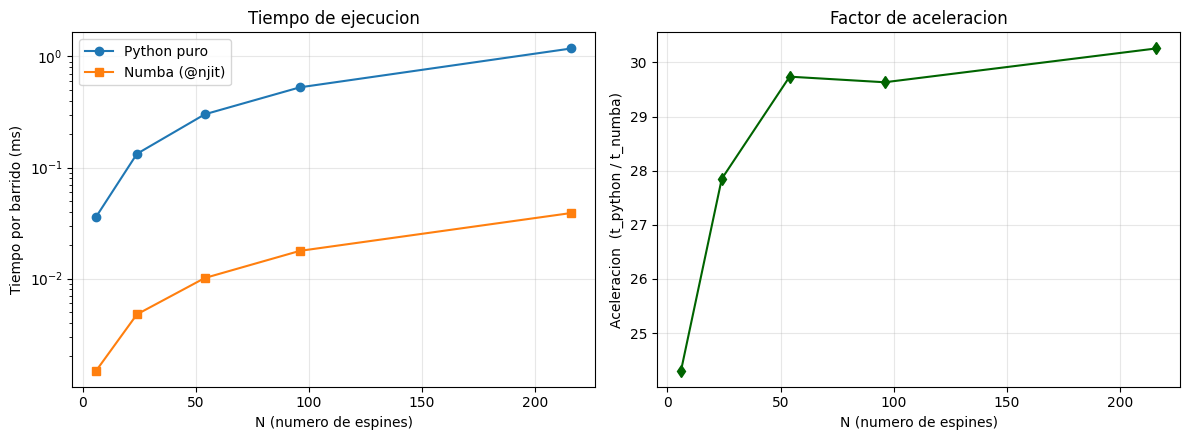

In [8]:
Ns    = [f[1] for f in filas]
t_pys = [f[2]*1e3 for f in filas]
t_nbs = [f[3]*1e3 for f in filas]
acels = [f[4]     for f in filas]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(Ns, t_pys, 'o-', label='Python puro')
ax1.plot(Ns, t_nbs, 's-', label='Numba (@njit)')
ax1.set_yscale('log')
ax1.set_xlabel('N (numero de espines)')
ax1.set_ylabel('Tiempo por barrido (ms)')
ax1.set_title('Tiempo de ejecucion')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(Ns, acels, 'd-', color='darkgreen')
ax2.set_xlabel('N (numero de espines)')
ax2.set_ylabel('Aceleracion  (t_python / t_numba)')
ax2.set_title('Factor de aceleracion')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_numba.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Extrapolación al costo real

Con el tiempo por barrido medido se puede estimar cuánto tardaría una corrida de
producción, usando los parámetros de `parametros.py`.

Número de barridos por tamaño L:

$$\text{barridos} = N_{\text{temps}} \times (N_{\text{term}} + N_{\text{skip}} \times N_{\text{meas}})$$

In [9]:
from parametros import N_temps, N_term, N_skip, N_meas

barridos_por_L = N_temps * (N_term + N_skip * N_meas)
print(f"Barridos por cada tamano L: {barridos_por_L:,}\n")

print(f"{'L':>3} {'N':>6} {'Python':>16} {'Numba':>16}")
print("-" * 45)
for L, N, t_py, t_nb, acel in filas:
    h_py = t_py * barridos_por_L / 3600
    h_nb = t_nb * barridos_por_L / 3600
    print(f"{L:3d} {N:6d} {h_py:13.2f} h {h_nb:13.2f} h")

print("\nNota: la extrapolacion es lineal en el numero de barridos y no incluye")
print("el costo de calcular_energia, que se ejecuta una vez por medida.")

Barridos por cada tamano L: 3,600,000

  L      N           Python            Numba
---------------------------------------------
  1      6          0.04 h          0.00 h
  2     24          0.13 h          0.00 h
  3     54          0.30 h          0.01 h
  4     96          0.53 h          0.02 h
  6    216          1.18 h          0.04 h

Nota: la extrapolacion es lineal en el numero de barridos y no incluye
el costo de calcular_energia, que se ejecuta una vez por medida.
